In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df = pd.read_csv("ai4i2020.csv.xls")

In [3]:
df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [8]:
df = df.drop("UDI", axis=1)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product ID               10000 non-null  object 
 1   Type                     10000 non-null  object 
 2   Air temperature [K]      10000 non-null  float64
 3   Process temperature [K]  10000 non-null  float64
 4   Rotational speed [rpm]   10000 non-null  int64  
 5   Torque [Nm]              10000 non-null  float64
 6   Tool wear [min]          10000 non-null  int64  
 7   Machine failure          10000 non-null  int64  
 8   TWF                      10000 non-null  int64  
 9   HDF                      10000 non-null  int64  
 10  PWF                      10000 non-null  int64  
 11  OSF                      10000 non-null  int64  
 12  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 1015.8+ KB


In [10]:
df.describe()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [11]:
# machine is working or unworking 
# if machine working -> 1
# if machine unworking (machine failure) -> 0

In [12]:
df

,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [33]:
df = df.drop("Product ID", axis=1)

In [18]:
df["Machine failure"].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

In [23]:
df_corr = df.corr(numeric_only=True)

In [27]:
future_matrix = df[(df_corr > 0.9)]

In [31]:
future_matrix.value_counts()

Series([], Name: count, dtype: int64)

In [32]:
# Air temperature [K] will drop.
# Label encoding alfabetik atama yapar. Low, High, Medium alfabetik olarak sıralanmaz. bu yüzden label encoding kısmına sözlük olarak{'L': 0, 'M': 1, 'H': 2} verilmesi gerek.
# train_test_split içerisine straitfy = y konulacak ki working kısmı test ve eğitim verisine eşit dağıtılsın. 

In [34]:
quality = {'L': 0, 'M': 1, 'H': 2}

In [35]:
df["Type"] = df["Type"].map(quality)

In [36]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,2,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,1,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,2,299.0,308.7,1408,48.5,25,0,0,0,0,0,0


In [37]:
columns_to_drop = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

In [38]:
df = df.drop(['TWF', 'HDF', 'PWF', 'OSF', 'RNF'], axis=1)

In [39]:
df

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,298.1,308.6,1551,42.8,0,0
1,0,298.2,308.7,1408,46.3,3,0
2,0,298.1,308.5,1498,49.4,5,0
3,0,298.2,308.6,1433,39.5,7,0
4,0,298.2,308.7,1408,40.0,9,0
...,...,...,...,...,...,...,...
9995,1,298.8,308.4,1604,29.5,14,0
9996,2,298.9,308.4,1632,31.8,17,0
9997,1,299.0,308.6,1645,33.4,22,0
9998,2,299.0,308.7,1408,48.5,25,0


In [43]:
from sklearn.model_selection import train_test_split

In [44]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify=y, random_state = 15)

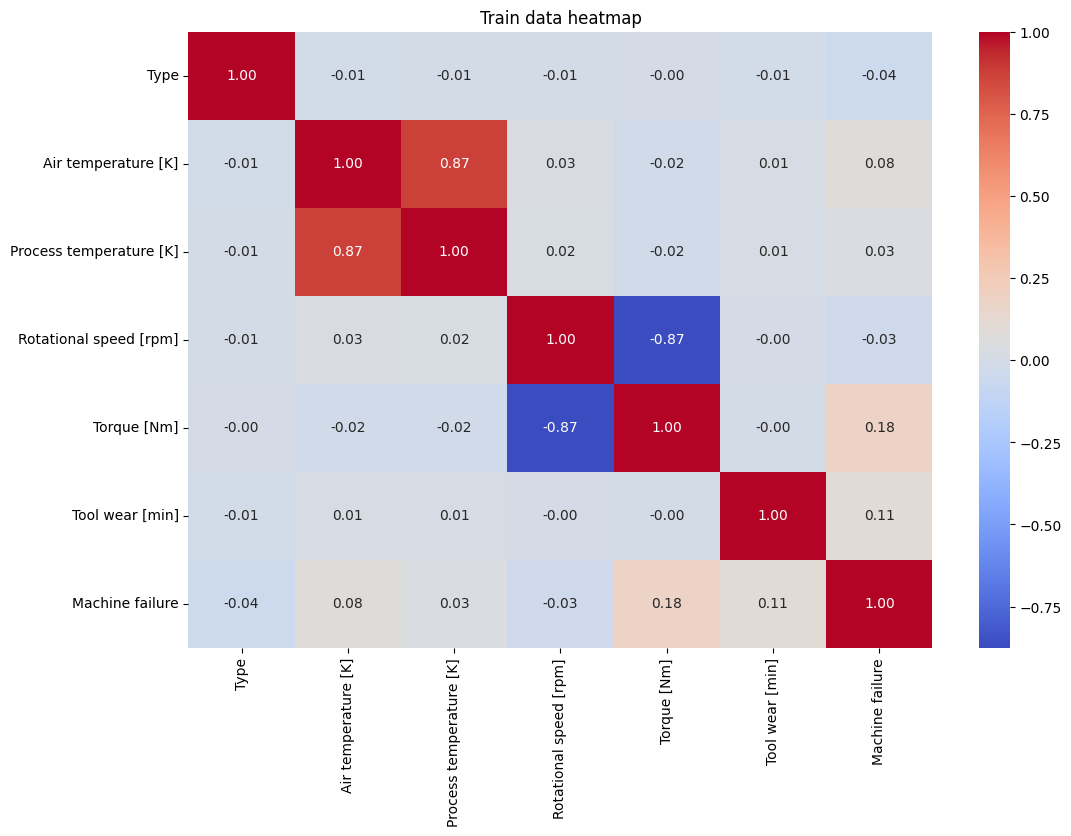

In [46]:
analiz_df = X_train.copy()
analiz_df['Machine failure'] = y_train

plt.figure(figsize=(12, 8))
sns.heatmap(analiz_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Train data heatmap")
plt.show()

<Axes: >

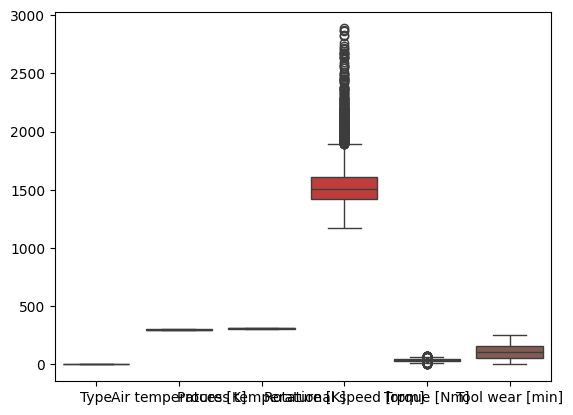

In [47]:
sns.boxplot(data = X_train)

<Axes: ylabel='Density'>

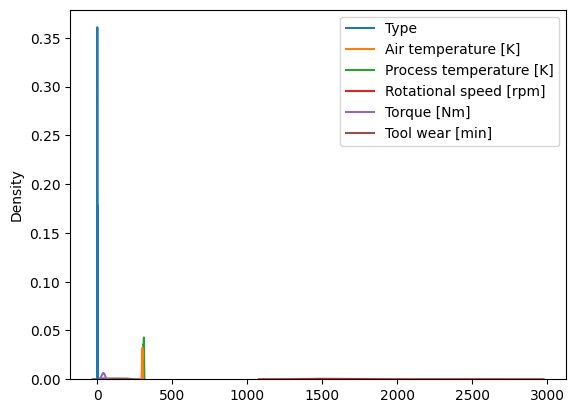

In [50]:
sns.kdeplot(data = X_train)

<Axes: >

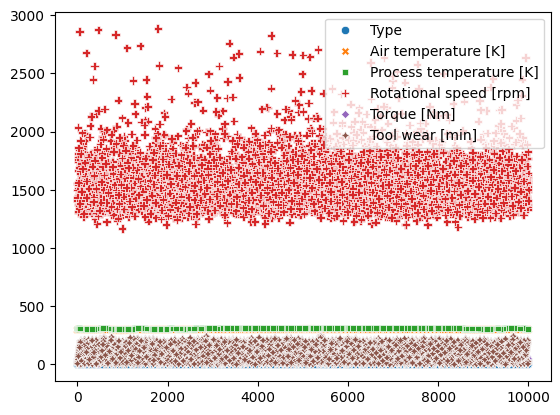

In [51]:
sns.scatterplot( data = X_train)

<Axes: xlabel='Rotational speed [rpm]', ylabel='Torque [Nm]'>

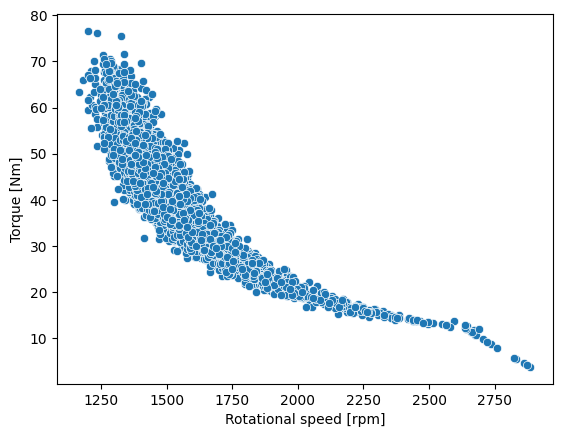

In [52]:
sns.scatterplot(data = X_train, x="Rotational speed [rpm]", y="Torque [Nm]")

In [53]:
from sklearn.preprocessing import StandardScaler

In [54]:
scaler = StandardScaler()

In [55]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [60]:
X_train_scaled

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,-0.741922,-1.155600,-0.747039,0.671408,-1.185121,-1.395081
1,-0.741922,-0.855774,-0.004967,-0.443009,0.767455,-0.102283
2,0.750879,-2.105051,-2.298644,-0.332671,0.326874,-0.244175
3,-0.741922,-1.055658,-1.489111,-0.448526,0.697362,-0.354536
4,0.750879,1.492868,0.737105,0.312808,-0.323985,1.316642
...,...,...,...,...,...,...
7995,0.750879,-0.705860,0.062494,0.307291,-0.694473,-1.458144
7996,0.750879,-2.254964,-2.770872,-0.884362,1.248089,1.490066
7997,-0.741922,0.743301,0.399800,0.207987,-0.584328,0.197268
7998,0.750879,-0.755832,-0.477194,-0.156129,-0.183800,0.985560


In [61]:
# feature engineering

In [62]:
X_train_scaled['Power_Factor'] = X_train_scaled['Rotational speed [rpm]'] * X_train_scaled['Torque [Nm]']
X_test_scaled['Power_Factor'] = X_test_scaled['Rotational speed [rpm]'] * X_test_scaled['Torque [Nm]']

In [63]:
cols_to_drop = ['Air temperature [K]']

X_train_scaled = X_train_scaled.drop(columns=cols_to_drop)
X_test_scaled = X_test_scaled.drop(columns=cols_to_drop)

In [83]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [66]:
oversample = SMOTE(random_state = 42)

In [68]:
X_train_smote, y_train_smote = oversample.fit_resample(X_train_scaled, y_train)

In [69]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')
lgb = LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1)

In [70]:
rf_smote = RandomForestClassifier(random_state=42)
lgb_smote = LGBMClassifier(random_state=42, verbose=-1)

In [72]:
import re

# Sütun isimlerindeki tüm özel karakterleri (parantezler, boşluklar vb.) alt çizgiyle (_) değiştiren fonksiyon
def clean_feature_names(df):
    # Regex ile sadece harf ve rakam olmayan her şeyi (veya boşlukları) _ yapıyoruz
    new_names = [re.sub(r'[^a-zA-Z0-9]', '_', col) for col in df.columns]
    # Yan yana birden fazla alt çizgi oluştuysa (örneğin a__b), tek bir alt çizgiye indirgiyoruz
    new_names = [re.sub(r'_+', '_', col).strip('_') for col in new_names]
    df.columns = new_names
    return df

# FAZ 6'dan hemen önce veri setlerimizin sütun isimlerini temizliyoruz
X_train_scaled = clean_feature_names(X_train_scaled)
X_test_scaled = clean_feature_names(X_test_scaled)
X_train_smote = clean_feature_names(X_train_smote)

print("LightGBM İçin Temizlenmiş Yeni Sütun İsimleri:")
print(X_train_scaled.columns.tolist())

LightGBM İçin Temizlenmiş Yeni Sütun İsimleri:
['Type', 'Process_temperature_K', 'Rotational_speed_rpm', 'Torque_Nm', 'Tool_wear_min', 'Power_Factor']


In [73]:
rf.fit(X_train_scaled, y_train)
lgb.fit(X_train_scaled, y_train)

rf_smote.fit(X_train_smote, y_train_smote)
rf_smote.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [75]:
rf.fit(X_train_scaled, y_train)
lgb.fit(X_train_scaled, y_train)

rf_smote.fit(X_train_smote, y_train_smote)
lgb_smote.fit(X_train_smote, y_train_smote)

#tahmin
preds_rf = rf.predict(X_test_scaled)
preds_lgb = lgb.predict(X_test_scaled)

preds_rf_smote = rf_smote.predict(X_test_scaled)
preds_lgb_smote = lgb_smote.predict(X_test_scaled)

In [77]:
print("=== SENARYO 1: Orijinal Veri + Random Forest ===")
print(classification_report(y_test, preds_rf, target_names=['Sağlam (0)', 'Arıza (1)']))

print("=== SENARYO 2: Orijinal Veri + LightGBM ===")
print(classification_report(y_test, preds_lgb, target_names=['Sağlam (0)', 'Arıza (1)']))

print("=== SENARYO 3: SMOTE Verisi + Random Forest ===")
print(classification_report(y_test, preds_rf_smote, target_names=['Sağlam (0)', 'Arıza (1)']))

print("=== SENARYO 4: SMOTE Verisi + LightGBM ===")
print(classification_report(y_test, preds_lgb_smote, target_names=['Sağlam (0)', 'Arıza (1)']))

=== SENARYO 1: Orijinal Veri + Random Forest ===
              precision    recall  f1-score   support

  Sağlam (0)       0.98      1.00      0.99      1932
   Arıza (1)       0.79      0.34      0.47        68

    accuracy                           0.97      2000
   macro avg       0.89      0.67      0.73      2000
weighted avg       0.97      0.97      0.97      2000

=== SENARYO 2: Orijinal Veri + LightGBM ===
              precision    recall  f1-score   support

  Sağlam (0)       0.99      0.97      0.98      1932
   Arıza (1)       0.44      0.69      0.53        68

    accuracy                           0.96      2000
   macro avg       0.71      0.83      0.76      2000
weighted avg       0.97      0.96      0.96      2000

=== SENARYO 3: SMOTE Verisi + Random Forest ===
              precision    recall  f1-score   support

  Sağlam (0)       0.99      0.95      0.97      1932
   Arıza (1)       0.34      0.69      0.46        68

    accuracy                           0.

In [78]:
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import GridSearchCV

In [79]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42, class_weight='balanced', verbose=-1))
])

In [80]:
param_grid = {
    'smote__k_neighbors': [3, 5, 7],
    
    'lgbm__num_leaves': [15, 31, 50],
    'lgbm__learning_rate': [0.01, 0.05, 0.1], 
    'lgbm__n_estimators': [100, 200]        
}

In [81]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,               
    scoring='recall',   
    n_jobs=-1,          
    verbose=1           
)

In [82]:
grid_search.fit(X_train_scaled, y_train)

for param, value in grid_search.best_params_.items():
    print(f" - {param}: {value}")

print(f"\n {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
 - lgbm__learning_rate: 0.01
 - lgbm__n_estimators: 100
 - lgbm__num_leaves: 15
 - smote__k_neighbors: 7

 0.9224


              precision    recall  f1-score   support

  Sağlam (0)       1.00      0.87      0.93      1932
   Arıza (1)       0.21      0.96      0.34        68

    accuracy                           0.88      2000
   macro avg       0.60      0.91      0.64      2000
weighted avg       0.97      0.88      0.91      2000



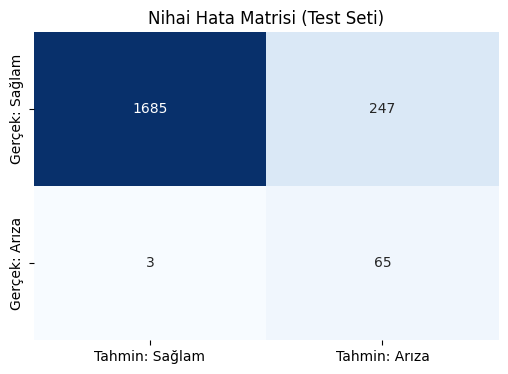

In [84]:
best_model = grid_search.best_estimator_

final_predictions = best_model.predict(X_test_scaled)

print("======")
print(classification_report(y_test, final_predictions, target_names=['Sağlam (0)', 'Arıza (1)']))
print("======")

cm = confusion_matrix(y_test, final_predictions)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Tahmin: Sağlam', 'Tahmin: Arıza'],
            yticklabels=['Gerçek: Sağlam', 'Gerçek: Arıza'])
plt.title("Nihai Hata Matrisi (Test Seti)")
plt.show()